Loading cached beta/beta_c1=0.2: figure2_beta_0p2_cache.npz
Loading cached beta/beta_c1=1: figure2_beta_1p0_cache.npz
Loading cached beta/beta_c1=4: figure2_beta_4p0_cache.npz
Saved: D:\坚果云\我的坚果云\课题2\note\submission\code-picture\fermi_polaron_figure2.png


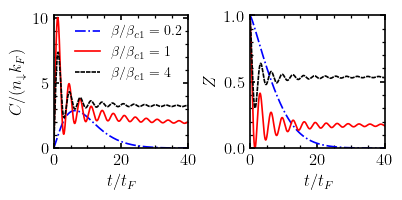

In [ ]:
"""Reproduce manuscript Fig. 2 for beta/beta_c1 = 0.2, 1, and 4.

This program uses the optimized trapezoidal/Hadamard solver and the numerical parameters of the original figure script:

    kF=1, n_q=100, dt=1/100, n_t=12000, n_seed=7.

Each curve is cached after it is calculated, so an interrupted or repeated run does not need to recompute completed beta values.  Use ``--recompute`` to
ignore the cache.
"""

from __future__ import annotations

from pathlib import Path
import argparse
import gc

import matplotlib.pyplot as plt
import numpy as np

from fermi_polaron_trapezoid_optimized import SolverConfig, run_simulation


plt.rc('text', usetex=True)


BETA_C1 = 2.0 * np.sqrt(2.0 / np.pi)
BETA_RATIOS = (0.2, 1.0, 4.0)


def cache_filename(ratio: float) -> Path:
    label = str(ratio).replace(".", "p")
    return Path(f"figure2_beta_{label}_cache.npz")


def cache_matches(data, config: SolverConfig, ratio: float) -> bool:
    """Check that cached data use exactly the requested discretization."""

    required = {"time", "contact", "residue", "beta", "dt", "n_q", "n_t", "n_seed"}
    if not required.issubset(data.files):
        return False
    return (
        np.isclose(float(data["beta"]), ratio * BETA_C1)
        and np.isclose(float(data["dt"]), config.dt)
        and int(data["n_q"]) == config.n_q
        and int(data["n_t"]) == config.n_t
        and int(data["n_seed"]) == config.n_seed
    )


def obtain_curve(
    ratio: float, base_config: SolverConfig, recompute: bool
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load a valid cache or calculate one beta curve."""

    cache = cache_filename(ratio)
    if cache.exists() and not recompute:
        with np.load(cache) as data:
            if cache_matches(data, base_config, ratio):
                print(f"Loading cached beta/beta_c1={ratio:g}: {cache}")
                return data["time"].copy(), data["contact"].copy(), data["residue"].copy()

    print(f"Calculating beta/beta_c1={ratio:g}")
    config = SolverConfig(
        beta=ratio * BETA_C1,
        kf=base_config.kf,
        n_q=base_config.n_q,
        dt=base_config.dt,
        n_t=base_config.n_t,
        n_seed=base_config.n_seed,
        show_progress=base_config.show_progress,
    )
    result = run_simulation(config)
    time_grid = result.time.copy()
    contact = result.contact.copy()
    residue = result.residue.copy()

    np.savez_compressed(
        cache,
        time=time_grid,
        contact=contact,
        residue=residue,
        beta=config.beta,
        dt=config.dt,
        n_q=config.n_q,
        n_t=config.n_t,
        n_seed=config.n_seed,
    )
    print(
        f"  minimum |SM denominator| = {result.min_rank1_denominator:.6e}; "
        f"saved {cache}"
    )

    # Fig. 2 needs only C and Z; release the much larger chi_qt array before calculating the next beta value.
    del result
    gc.collect()
    return time_grid, contact, residue


def draw_figure2(
    curves: dict[float, tuple[np.ndarray, np.ndarray, np.ndarray]],
    # pdf_output: Path,
    png_output: Path,
) -> None:
    """Draw the two-panel figure using Matplotlib mathtext (no LaTeX install)."""

    styles = {
        0.2: dict(color="blue", linestyle="-.", linewidth=1.2),
        1.0: dict(color="red", linestyle="-", linewidth=1.2),
        4.0: dict(color="black", linestyle=(0, (2.7, 0.6, 2.7, 0.6)), linewidth=1.2),
    }

    fig = plt.figure(figsize=(3.375, 1.66))
    grid = fig.add_gridspec(
        nrows=100,
        ncols=100,
        left=0.01,
        bottom=0.08,
        right=0.99,
        top=0.97,
        wspace=1.0,
        hspace=1.0,
    )
    ax_contact = fig.add_subplot(grid[0:90, 0:41])
    ax_residue = fig.add_subplot(grid[0:90, 59:100])

    for axis in (ax_contact, ax_residue):
        for spine in axis.spines.values():
            spine.set_linewidth(1.2)
        axis.tick_params(
            axis="both",
            which="major",
            direction="in",
            labelsize=12,
            width=1.2,
            top=True,
            right=True,
        )
        axis.minorticks_on()
        axis.tick_params(
            axis="both",
            which="minor",
            direction="in",
            width=0.9,
            top=True,
            right=True,
            labelsize=0,
        )

    # ax_contact.text(-0.35, 0.97, "(a)", transform=ax_contact.transAxes)
    # ax_residue.text(-0.38, 0.97, "(b)", transform=ax_residue.transAxes)

    for ratio in BETA_RATIOS:
        time_grid, contact, residue = curves[ratio]
        # In kF=m=1 units, epsilon_F=1/2 and t_F=2, hence t/t_F=t/2.
        time_over_t_f = time_grid / 2.0
        label = rf"$\beta/\beta_{{c1}}={ratio:g}$"
        ax_contact.plot(time_over_t_f, contact, label=label, **styles[ratio])
        ax_residue.plot(time_over_t_f, residue, label=label, **styles[ratio])

    ax_contact.set_xlim(0.0, 40.0)
    ax_contact.set_ylim(0.0, 10.2)
    ax_contact.legend(
        loc="upper right",
        bbox_to_anchor=(1.04, 1.02),
        fontsize=10,
        frameon=False,
        handlelength=1.8,
    )
    ax_contact.set_xlabel(r"$t/t_F$", fontsize=12)
    ax_contact.set_ylabel(r"$C/(n_{\downarrow}k_F)$", fontsize=12)

    ax_residue.set_xlim(0.0, 40.0)
    ax_residue.set_ylim(0.0, 1.0)
    ax_residue.set_xlabel(r"$t/t_F$", fontsize=12)
    ax_residue.set_ylabel(r"$Z$", fontsize=12)

    fig.patch.set_alpha(0.0)
    ax_contact.set_facecolor("none")
    ax_residue.set_facecolor("none")

    '''fig.savefig(
        pdf_output,
        bbox_inches="tight",
        transparent=True,
    )'''

    fig.savefig(
        png_output,
        dpi=600,
        bbox_inches="tight",
        transparent=True,
    )

    # print(f"Saved: {pdf_output.resolve()}")
    print(f"Saved: {png_output.resolve()}")
    plt.show()


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--quick-test", action="store_true")
    parser.add_argument("--recompute", action="store_true")
    '''parser.add_argument(
        "--pdf", type=Path, default=Path("fermi_polaron_figure2.pdf")
    )'''
    parser.add_argument(
        "--png", type=Path, default=Path("fermi_polaron_figure2.png")
    )
    args, _unknown = parser.parse_known_args()  # compatible with Jupyter
    return args


def main() -> None:
    args = parse_args()
    if args.quick_test:
        base_config = SolverConfig(
            n_q=20,
            dt=1.0 / 100.0,
            n_t=160,
            n_seed=7,
            show_progress=False,
        )
    else:
        base_config = SolverConfig(
            n_q=100,
            dt=1.0 / 100.0,
            n_t=12_000,
            n_seed=7,
        )

    curves = {
        ratio: obtain_curve(ratio, base_config, args.recompute)
        for ratio in BETA_RATIOS
    }
    draw_figure2(curves, args.png)# , args.pdf, args.png)


if __name__ == "__main__":
    main()

